# 07 Error Analysis: Linear vs CatBoost

Notebook นี้เทียบเฉพาะโมเดล 2 family เพื่อดูว่าเคสไหนที่โมเดลทายต่างกันและเพราะอะไร:

- **Linear:** Logistic Regression บน all-features แบบเดียวกับ notebook 05
- **Tree-based:** CatBoost บน all-features โดยใช้ cached best params จาก notebook modeling/ROC ถ้ามี

เป้าหมายหลักคือหา `linear wrong / tree correct`, `linear correct / tree wrong`, และ `both wrong` แล้วดู signal สำคัญ เช่น gold, CS, kill, damage, KDA และ objective diff.


In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report, confusion_matrix
from catboost import CatBoostClassifier

RANDOM_STATE = 1337
DATA_PATH = Path('data/t2_transformed/merged_v1.csv')
OUTPUT_DIR = Path('outputs/error_analysis')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid')


## 1. Load And Clean Data

ใช้ cleaning policy เดียวกับ notebook 03/04/05: drop id columns, เอา `RedWin` ออกเพื่อกัน target leakage, และ normalize lane `NONE` เป็น `JUNGLE`.

In [2]:
df = pd.read_csv(DATA_PATH)
raw_rows, raw_cols = df.shape

# Basic cleaning from the modeling notebooks.
df = df.drop(columns=[c for c in ['MatchFk', 'Patch'] if c in df.columns], errors='ignore')
df = df[df['BlueWin'] != df['RedWin']].reset_index(drop=True)
df = df.drop(columns=['RedWin'], errors='ignore')
df['BlueWin'] = df['BlueWin'].astype(int)

lane_cols = [f'Lane_P{p}' for p in range(1, 11)]
for c in lane_cols:
    if c in df.columns:
        df[c] = df[c].replace('NONE', 'JUNGLE')

summary_load = pd.DataFrame([
    {'item': 'raw rows', 'value': raw_rows},
    {'item': 'raw columns', 'value': raw_cols},
    {'item': 'clean rows', 'value': len(df)},
    {'item': 'clean columns before encoding', 'value': df.shape[1]},
    {'item': 'blue win ratio', 'value': df['BlueWin'].mean()},
])
display(summary_load)

,item,value
0,raw rows,91411.000000
1,raw columns,145.000000
2,clean rows,91394.000000
3,clean columns before encoding,142.000000
4,blue win ratio,0.500055


## 2. Build All-Features Matrix

ขั้นนี้ทำให้ใกล้ notebook 05: champion composition เป็น team-level multi-hot, rune/spell/lane/queue encode เป็น dummy variables, แล้วเติม aggregate/difference features.

In [3]:
# Champion composition: team-level multi-hot encoding.
blue_champ_cols = [f'ChampionFk_P{p}' for p in range(1, 6) if f'ChampionFk_P{p}' in df.columns]
red_champ_cols = [f'ChampionFk_P{p}' for p in range(6, 11) if f'ChampionFk_P{p}' in df.columns]
champion_cols = blue_champ_cols + red_champ_cols

blue_champs = df[blue_champ_cols].astype('Int64').astype(str)
red_champs = df[red_champ_cols].astype('Int64').astype(str)
champion_ids = (
    pd.concat([blue_champs.stack(), red_champs.stack()], axis=0)
    .replace('<NA>', np.nan)
    .dropna()
    .sort_values()
    .unique()
)

champion_features = {}
for champ_id in champion_ids:
    champion_features[f'BlueChamp_{champ_id}'] = blue_champs.eq(champ_id).any(axis=1).astype(int)
    champion_features[f'RedChamp_{champ_id}'] = red_champs.eq(champ_id).any(axis=1).astype(int)

df_model = pd.concat(
    [df.drop(columns=champion_cols, errors='ignore'), pd.DataFrame(champion_features, index=df.index)],
    axis=1,
)

# Other categorical ID columns.
categorical_id_prefixes = ('PrimaryKeyStone_', 'SummonerSpell1_', 'SummonerSpell2_')
for c in [c for c in df_model.columns if c.startswith(categorical_id_prefixes)]:
    df_model[c] = df_model[c].astype('Int64').astype(str)

ohe_cols = df_model.select_dtypes(include=['object', 'category']).columns.tolist()
df_model = pd.get_dummies(df_model, columns=ohe_cols, dummy_na=False)

# Aggregate engineering from notebooks 04/05.
blue_players = [f'P{i}' for i in range(1, 6)]
red_players = [f'P{i}' for i in range(6, 11)]

for stat in ['TotalGold', 'MinionsKilled', 'kills', 'deaths', 'assists', 'DmgDealt']:
    blue_cols = [f'{stat}_{p}' for p in blue_players]
    red_cols = [f'{stat}_{p}' for p in red_players]
    if all(c in df_model.columns for c in blue_cols + red_cols):
        df_model[f'Blue_{stat}_sum'] = df_model[blue_cols].sum(axis=1)
        df_model[f'Red_{stat}_sum'] = df_model[red_cols].sum(axis=1)
        df_model[f'Blue_{stat}_avg'] = df_model[blue_cols].mean(axis=1)
        df_model[f'Red_{stat}_avg'] = df_model[red_cols].mean(axis=1)
        df_model[f'Diff_{stat}'] = df_model[f'Blue_{stat}_sum'] - df_model[f'Red_{stat}_sum']

def safe_kda(k, d, a):
    return (k + a) / d.replace(0, 1)

kda_required = {'Blue_kills_sum', 'Blue_deaths_sum', 'Blue_assists_sum', 'Red_kills_sum', 'Red_deaths_sum', 'Red_assists_sum'}
if kda_required.issubset(df_model.columns):
    df_model['Blue_KDA'] = safe_kda(df_model['Blue_kills_sum'], df_model['Blue_deaths_sum'], df_model['Blue_assists_sum'])
    df_model['Red_KDA'] = safe_kda(df_model['Red_kills_sum'], df_model['Red_deaths_sum'], df_model['Red_assists_sum'])
    df_model['Diff_KDA'] = df_model['Blue_KDA'] - df_model['Red_KDA']

for obj in ['BaronKills', 'RiftHeraldKills', 'DragonKills', 'TowerKills']:
    blue_col = f'Blue{obj}'
    red_col = f'Red{obj}'
    if blue_col in df_model.columns and red_col in df_model.columns:
        df_model[f'Diff_{obj}'] = df_model[blue_col] - df_model[red_col]

if 'BlueKills' in df_model.columns and 'RedKills' in df_model.columns:
    df_model['Diff_Kills'] = df_model['BlueKills'] - df_model['RedKills']

for side, players in [('Blue', blue_players), ('Red', red_players)]:
    gold_cols = [f'TotalGold_{p}' for p in players]
    if all(c in df_model.columns for c in gold_cols):
        df_model[f'{side}_GoldStd'] = df_model[gold_cols].std(axis=1)

X = df_model.drop(columns=['BlueWin']).replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))
y = df_model['BlueWin']

feature_summary = pd.DataFrame([
    {'item': 'feature count after all encoding/engineering', 'value': X.shape[1]},
    {'item': 'champion ids encoded', 'value': len(champion_ids)},
    {'item': 'dummy columns created from object columns', 'value': len(ohe_cols)},
])
display(feature_summary)

,item,value
0,feature count after all encoding/engineering,959
1,champion ids encoded,172
2,dummy columns created from object columns,41


In [4]:
def feature_group(col):
    if col.startswith(('BlueChamp_', 'RedChamp_')):
        return 'champion_composition'
    if col.startswith('Lane_'):
        return 'lane_position'
    if col.startswith(('PrimaryKeyStone_', 'SummonerSpell1_', 'SummonerSpell2_')):
        return 'setup_runes_spells'
    if col.startswith('QueueType_'):
        return 'queue_type'
    if col.startswith('Diff_'):
        return 'aggregate_difference'
    if col in {
        'BlueBaronKills', 'BlueRiftHeraldKills', 'BlueDragonKills', 'BlueTowerKills', 'BlueKills',
        'RedBaronKills', 'RedRiftHeraldKills', 'RedDragonKills', 'RedTowerKills', 'RedKills',
    }:
        return 'objective_counts'
    if '_P' in col:
        return 'player_level_stats'
    if col.startswith(('Blue_', 'Red_')):
        return 'team_aggregate'
    return 'other'

feature_group_table = (
    pd.Series([feature_group(c) for c in X.columns])
    .value_counts()
    .rename_axis('feature_group')
    .reset_index(name='feature_count')
)
display(feature_group_table)

,feature_group,feature_count
0,setup_runes_spells,430
1,champion_composition,344
2,player_level_stats,80
3,lane_position,50
4,team_aggregate,28
5,aggregate_difference,12
6,objective_counts,10
7,queue_type,5


## 3. Train Linear And Tree-Based Models

ใช้ split เดียวกับ notebook modeling เดิม: train 70%, validation 15%, test 15%. Logistic Regression ใช้ `StandardScaler`; CatBoost ใช้ raw numeric features และ validation set สำหรับ early stopping.


In [5]:
temp_size = 0.30
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=temp_size, random_state=RANDOM_STATE, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

linear_model = LogisticRegression(C=1.0, solver='lbfgs', penalty='l2', max_iter=500, random_state=42)
linear_model.fit(X_train_sc, y_train)
linear_prob = linear_model.predict_proba(X_test_sc)[:, 1]
linear_pred = (linear_prob >= 0.50).astype(int)

INT_PARAMS = {'max_depth', 'min_samples_leaf', 'n_estimators', 'min_child_weight', 'num_leaves', 'min_child_samples', 'depth'}

def clean_cached_param_value(key, value):
    if pd.isna(value) or value == '':
        return None
    if isinstance(value, str):
        value = value.strip()
        if value == '' or value.lower() == 'nan' or value == 'None':
            return None
    if key in INT_PARAMS:
        return int(float(value))
    if isinstance(value, str):
        try:
            return float(value)
        except ValueError:
            return value
    return value

def load_params(path='outputs/all_features/best_params.csv'):
    params_path = Path(path)
    if not params_path.exists():
        return {}
    params_table = pd.read_csv(params_path, index_col=0)
    params = {}
    for model_name, row in params_table.iterrows():
        cleaned = {}
        for key, value in row.items():
            v = clean_cached_param_value(key, value)
            if v is not None:
                cleaned[key] = v
        params[model_name] = cleaned
    return params

catboost_params = load_params().get('CatBoost', {})
tree_model = CatBoostClassifier(
    **catboost_params,
    iterations=800,
    random_seed=42,
    verbose=0,
    early_stopping_rounds=50,
    allow_writing_files=False,
)
tree_model.fit(X_train.values, y_train.values, eval_set=(X_val.values, y_val.values))
tree_prob = tree_model.predict_proba(X_test.values)[:, 1]
tree_pred = (tree_prob >= 0.50).astype(int)

metrics = pd.DataFrame([
    {
        'model_family': 'linear',
        'model': 'LogisticRegression',
        'test_accuracy': accuracy_score(y_test, linear_pred),
        'test_auc': roc_auc_score(y_test, linear_prob),
        'test_f1': f1_score(y_test, linear_pred),
    },
    {
        'model_family': 'tree_based',
        'model': 'CatBoostClassifier',
        'test_accuracy': accuracy_score(y_test, tree_pred),
        'test_auc': roc_auc_score(y_test, tree_prob),
        'test_f1': f1_score(y_test, tree_pred),
    },
])
metrics.to_csv(OUTPUT_DIR / 'model_metrics.csv', index=False)
display(metrics)

print('Linear model classification report')
print(classification_report(y_test, linear_pred, target_names=['Red Win', 'Blue Win']))
print('Tree-based model classification report')
print(classification_report(y_test, tree_pred, target_names=['Red Win', 'Blue Win']))


,model_family,model,test_accuracy,test_auc,test_f1
0,linear,LogisticRegression,0.717433,0.797066,0.715691
1,tree_based,CatBoostClassifier,0.716047,0.798892,0.713138


Linear model classification report
              precision    recall  f1-score   support

     Red Win       0.71      0.72      0.72      6854
    Blue Win       0.72      0.71      0.72      6856

    accuracy                           0.72     13710
   macro avg       0.72      0.72      0.72     13710
weighted avg       0.72      0.72      0.72     13710

Tree-based model classification report
              precision    recall  f1-score   support

     Red Win       0.71      0.73      0.72      6854
    Blue Win       0.72      0.71      0.71      6856

    accuracy                           0.72     13710
   macro avg       0.72      0.72      0.72     13710
weighted avg       0.72      0.72      0.72     13710



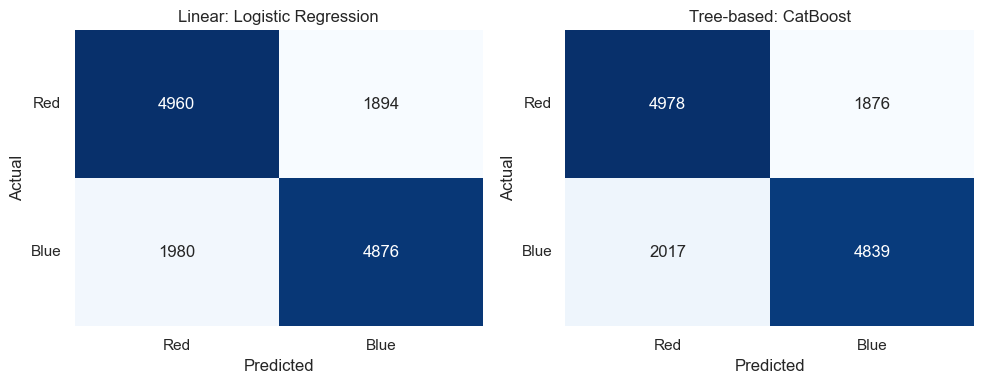

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, pred, title in [
    (axes[0], linear_pred, 'Linear: Logistic Regression'),
    (axes[1], tree_pred, 'Tree-based: CatBoost'),
]:
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticklabels(['Red', 'Blue'])
    ax.set_yticklabels(['Red', 'Blue'], rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Prediction Disagreement Buckets

สร้าง bucket หลัก 4 แบบ:

- `both_correct`: ทายถูกทั้งคู่
- `linear_correct_tree_wrong`: linear ถูก แต่ tree ผิด
- `linear_wrong_tree_correct`: linear ผิด แต่ tree ถูก
- `both_wrong`: ผิดทั้งคู่

In [7]:
cases = pd.DataFrame({
    'actual': y_test.values,
    'linear_pred': linear_pred,
    'linear_prob_blue': linear_prob,
    'tree_pred': tree_pred,
    'tree_prob_blue': tree_prob,
}, index=X_test.index)

cases['linear_correct'] = cases['linear_pred'].eq(cases['actual'])
cases['tree_correct'] = cases['tree_pred'].eq(cases['actual'])
cases['linear_margin'] = (cases['linear_prob_blue'] - 0.5).abs()
cases['tree_margin'] = (cases['tree_prob_blue'] - 0.5).abs()
cases['prob_gap_tree_minus_linear'] = cases['tree_prob_blue'] - cases['linear_prob_blue']
cases['abs_prob_gap'] = cases['prob_gap_tree_minus_linear'].abs()

conditions = [
    cases['linear_correct'] & cases['tree_correct'],
    cases['linear_correct'] & ~cases['tree_correct'],
    ~cases['linear_correct'] & cases['tree_correct'],
    ~cases['linear_correct'] & ~cases['tree_correct'],
]
choices = ['both_correct', 'linear_correct_tree_wrong', 'linear_wrong_tree_correct', 'both_wrong']
cases['case_bucket'] = np.select(conditions, choices, default='other')

case_counts = (
    cases['case_bucket']
    .value_counts()
    .rename_axis('case_bucket')
    .reset_index(name='count')
)
case_counts['share'] = case_counts['count'] / len(cases)
case_counts.to_csv(OUTPUT_DIR / 'case_bucket_counts.csv', index=False)
display(case_counts)

cases.to_csv(OUTPUT_DIR / 'prediction_disagreement_cases.csv', index_label='row_index')
cases[cases['case_bucket'] == 'both_wrong'].to_csv(OUTPUT_DIR / 'both_wrong_cases.csv', index_label='row_index')
cases[cases['case_bucket'] == 'linear_wrong_tree_correct'].to_csv(OUTPUT_DIR / 'linear_wrong_tree_correct_cases.csv', index_label='row_index')
cases[cases['case_bucket'] == 'linear_correct_tree_wrong'].to_csv(OUTPUT_DIR / 'linear_correct_tree_wrong_cases.csv', index_label='row_index')

,case_bucket,count,share
0,both_correct,9201,0.671116
1,both_wrong,3258,0.237637
2,linear_correct_tree_wrong,635,0.046317
3,linear_wrong_tree_correct,616,0.044931


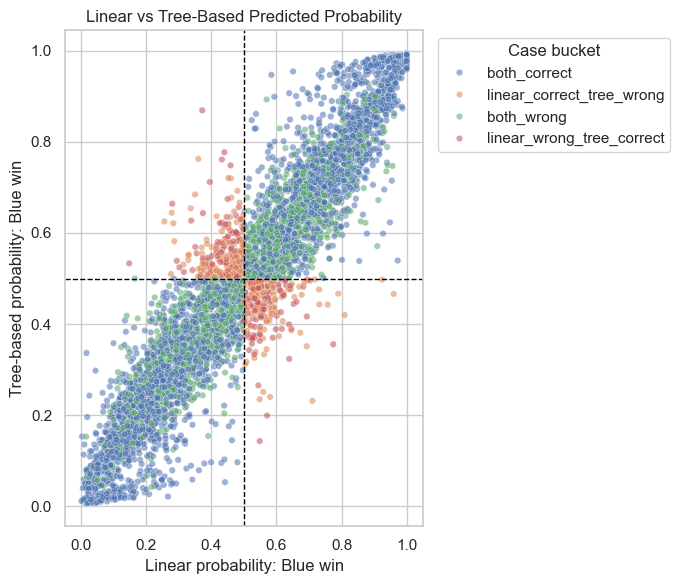

In [8]:
plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=cases.sample(min(len(cases), 5000), random_state=RANDOM_STATE),
    x='linear_prob_blue',
    y='tree_prob_blue',
    hue='case_bucket',
    alpha=0.55,
    s=22,
)
plt.axvline(0.5, color='black', linestyle='--', linewidth=1)
plt.axhline(0.5, color='black', linestyle='--', linewidth=1)
plt.title('Linear vs Tree-Based Predicted Probability')
plt.xlabel('Linear probability: Blue win')
plt.ylabel('Tree-based probability: Blue win')
plt.legend(title='Case bucket', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'probability_disagreement_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Why Do They Differ?

ดูค่าเฉลี่ยของ early-game signals แยกตาม bucket เพื่อหา pattern ว่า tree ชนะ linear ในเคสแบบไหน และทั้งคู่พลาดในสถานการณ์แบบใด.

In [9]:
key_signal_cols = [
    'Diff_TotalGold', 'Diff_MinionsKilled', 'Diff_kills', 'Diff_DmgDealt', 'Diff_KDA',
    'Diff_DragonKills', 'Diff_TowerKills', 'Diff_Kills',
    'Blue_TotalGold_sum', 'Red_TotalGold_sum', 'BlueKills', 'RedKills',
    'BlueDragonKills', 'RedDragonKills', 'BlueTowerKills', 'RedTowerKills',
]
key_signal_cols = [c for c in key_signal_cols if c in X_test.columns]

analysis_df = cases.join(X_test[key_signal_cols])
bucket_signal_summary = (
    analysis_df
    .groupby('case_bucket')[key_signal_cols + ['linear_prob_blue', 'tree_prob_blue', 'linear_margin', 'tree_margin']]
    .mean()
    .reset_index()
)
bucket_signal_summary['count'] = bucket_signal_summary['case_bucket'].map(cases['case_bucket'].value_counts())
bucket_signal_summary.to_csv(OUTPUT_DIR / 'bucket_signal_summary.csv', index=False)
display(bucket_signal_summary.sort_values('count', ascending=False))

,case_bucket,Diff_TotalGold,Diff_MinionsKilled,Diff_kills,Diff_DmgDealt,Diff_KDA,Diff_DragonKills,Diff_TowerKills,Diff_Kills,Blue_TotalGold_sum,...,RedKills,BlueDragonKills,RedDragonKills,BlueTowerKills,RedTowerKills,linear_prob_blue,tree_prob_blue,linear_margin,tree_margin,count
0,both_correct,-32.538202,-1.478644,0.083034,40.944897,0.061231,-0.080861,-0.001304,-0.409738,19473.101619,...,8.667536,0.381698,0.462558,0.102706,0.104010,0.503952,0.504905,0.266260,0.253898,9201
1,both_wrong,-17.474217,-1.523634,0.070902,-47.201657,0.066414,-0.091774,-0.013505,0.151013,18856.766421,...,7.699202,0.380295,0.472069,0.055556,0.069061,0.490014,0.489083,0.177370,0.159152,3258
2,linear_correct_tree_wrong,120.059843,-1.299213,0.401575,148.853543,0.222482,-0.062992,0.003150,0.481890,19538.292913,...,7.541732,0.385827,0.448819,0.099213,0.096063,0.504883,0.496369,0.067483,0.056072,635
3,linear_wrong_tree_correct,47.349026,0.402597,0.258117,166.873377,0.122796,-0.129870,-0.008117,0.337662,19580.936688,...,7.980519,0.342532,0.472403,0.084416,0.092532,0.499823,0.499674,0.063523,0.066058,616


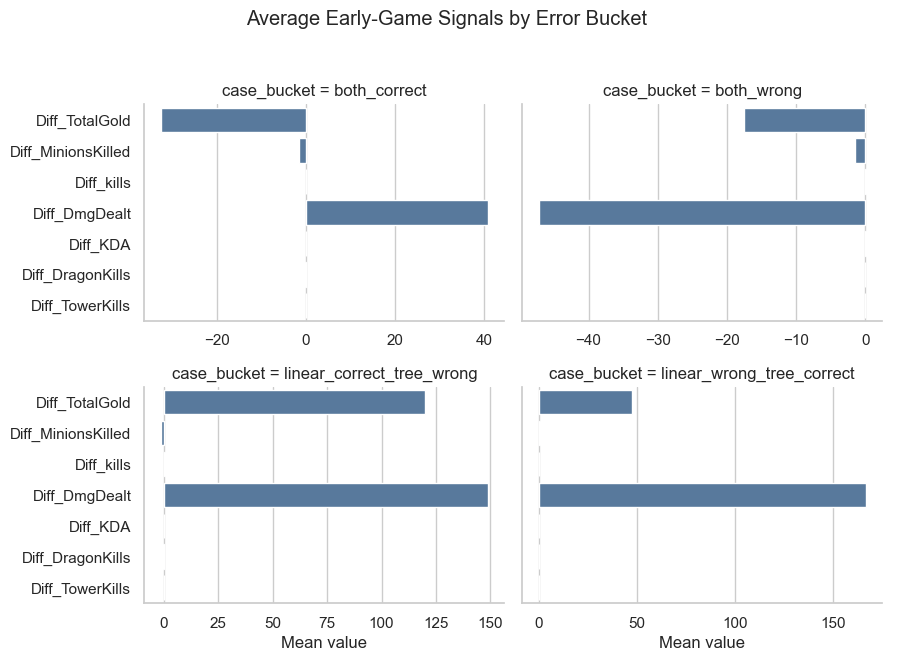

In [10]:
plot_cols = [c for c in ['Diff_TotalGold', 'Diff_MinionsKilled', 'Diff_kills', 'Diff_DmgDealt', 'Diff_KDA', 'Diff_DragonKills', 'Diff_TowerKills'] if c in analysis_df.columns]
if plot_cols:
    plot_data = analysis_df.groupby('case_bucket')[plot_cols].mean().reset_index().melt(
        id_vars='case_bucket', var_name='signal', value_name='mean_value'
    )
    g = sns.catplot(
        data=plot_data,
        x='mean_value',
        y='signal',
        col='case_bucket',
        kind='bar',
        col_wrap=2,
        sharex=False,
        height=3.2,
        aspect=1.4,
        color='#4C78A8',
    )
    g.fig.suptitle('Average Early-Game Signals by Error Bucket', y=1.03)
    g.set_axis_labels('Mean value', '')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'bucket_signal_summary.png', dpi=150, bbox_inches='tight')
    plt.show()

## 6. Global Model Signals

Linear model ใช้ coefficient หลัง scaling จึงเห็นทิศทาง Blue/Red ได้ชัด ส่วน CatBoost ใช้ feature importance จึงบอกว่า feature ไหนช่วยแยก prediction ได้มาก แต่ไม่ได้บอกทิศทางโดยตรงเหมือน coefficient.


In [11]:
linear_coef = pd.DataFrame({
    'feature': X.columns,
    'coefficient': linear_model.coef_[0],
})
linear_coef['importance'] = linear_coef['coefficient'].abs()
linear_coef['direction'] = np.where(linear_coef['coefficient'] >= 0, 'Blue-favored', 'Red-favored')
linear_coef['feature_group'] = linear_coef['feature'].map(feature_group)
linear_coef = linear_coef.sort_values('importance', ascending=False).reset_index(drop=True)
linear_coef['rank'] = np.arange(1, len(linear_coef) + 1)
linear_coef.to_csv(OUTPUT_DIR / 'linear_coefficients.csv', index=False)

tree_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': tree_model.feature_importances_,
})
tree_importance['feature_group'] = tree_importance['feature'].map(feature_group)
tree_importance = tree_importance.sort_values('importance', ascending=False).reset_index(drop=True)
tree_importance['rank'] = np.arange(1, len(tree_importance) + 1)
tree_importance.to_csv(OUTPUT_DIR / 'tree_feature_importance.csv', index=False)

display(linear_coef.head(20))
display(tree_importance.head(20))

,feature,coefficient,importance,direction,feature_group,rank
0,Diff_TotalGold,0.372307,0.372307,Blue-favored,aggregate_difference,1
1,Diff_DmgDealt,0.217100,0.217100,Blue-favored,aggregate_difference,2
2,Diff_MinionsKilled,0.199794,0.199794,Blue-favored,aggregate_difference,3
3,TotalGold_P1,0.189584,0.189584,Blue-favored,player_level_stats,4
4,TotalGold_P8,-0.158852,0.158852,Red-favored,player_level_stats,5
5,MinionsKilled_P7,-0.138989,0.138989,Red-favored,player_level_stats,6
6,MinionsKilled_P2,0.136728,0.136728,Blue-favored,player_level_stats,7
7,TotalGold_P4,0.124745,0.124745,Blue-favored,player_level_stats,8
8,BlueChamp_81,-0.121275,0.121275,Red-favored,champion_composition,9
9,RedChamp_81,0.113221,0.113221,Blue-favored,champion_composition,10


,feature,importance,feature_group,rank
0,Diff_TotalGold,18.139162,aggregate_difference,1
1,PrimaryKeyStone_P6_0,4.862221,setup_runes_spells,2
2,Lane_P5_JUNGLE,3.884886,lane_position,3
3,PrimaryKeyStone_P9_0,3.798333,setup_runes_spells,4
4,PrimaryKeyStone_P7_0,3.650786,setup_runes_spells,5
5,Red_MinionsKilled_sum,2.998262,team_aggregate,6
6,Diff_MinionsKilled,2.530225,aggregate_difference,7
7,Lane_P4_JUNGLE,2.355303,lane_position,8
8,Red_MinionsKilled_avg,1.701864,team_aggregate,9
9,RedDragonKills,1.421402,objective_counts,10


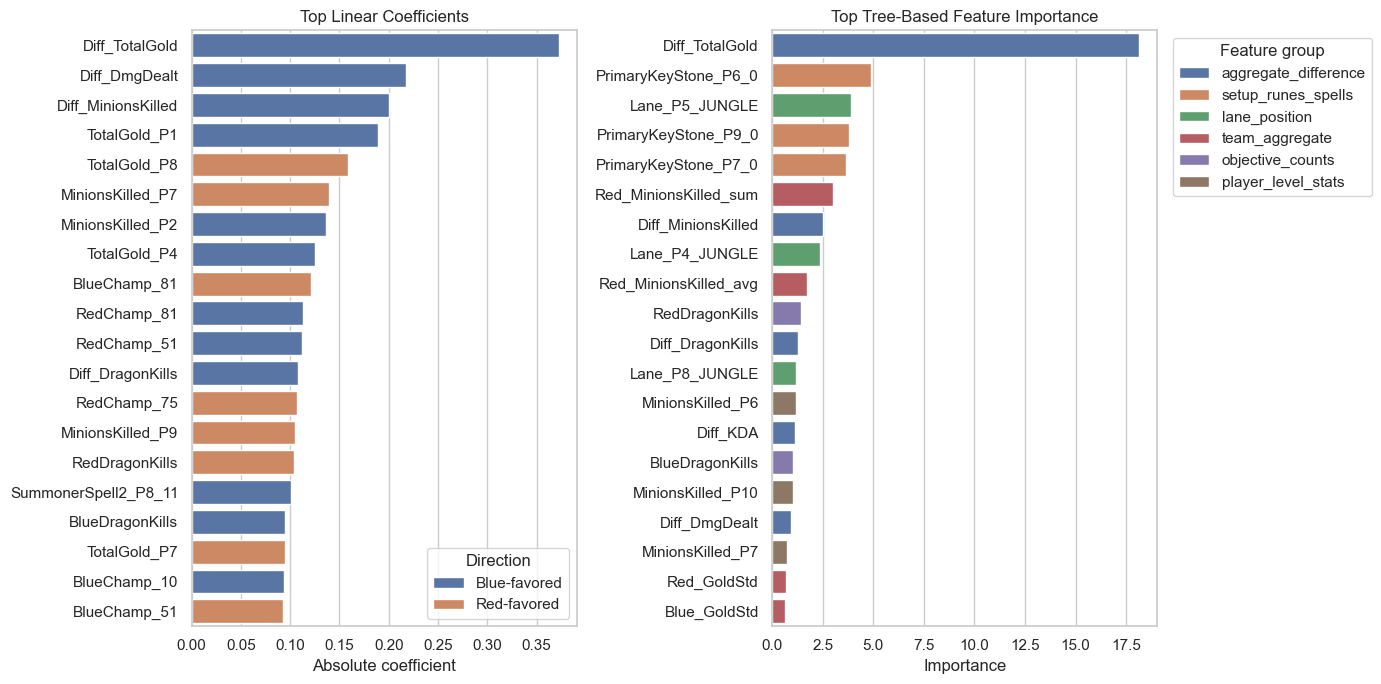

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
sns.barplot(data=linear_coef.head(20), x='importance', y='feature', hue='direction', dodge=False, ax=axes[0])
axes[0].set_title('Top Linear Coefficients')
axes[0].set_xlabel('Absolute coefficient')
axes[0].set_ylabel('')
axes[0].legend(title='Direction')

sns.barplot(data=tree_importance.head(20), x='importance', y='feature', hue='feature_group', dodge=False, ax=axes[1])
axes[1].set_title('Top Tree-Based Feature Importance')
axes[1].set_xlabel('Importance')
axes[1].set_ylabel('')
axes[1].legend(title='Feature group', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'global_model_signals.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Case-Level Explanation Helpers

สำหรับแต่ละ row:

- `linear_top_contributions`: feature ที่ดัน logit ไปทาง Blue/Red มากสุด
- `top_raw_signals`: early-game diff ที่เด่นที่สุดของเกมนั้น
- `tree_top_feature_values`: ค่า feature สำคัญของ tree ใน row นั้น เพื่อดูว่า tree น่าจะสนใจ signal อะไร

In [13]:
train_means = X_train.mean()
train_stds = X_train.std().replace(0, np.nan)
coef_series = pd.Series(linear_model.coef_[0], index=X.columns)
rf_top_features = tree_importance.head(40)['feature'].tolist()

signal_direction_cols = [c for c in key_signal_cols if c.startswith('Diff_') or c in ['BlueKills', 'RedKills', 'BlueDragonKills', 'RedDragonKills', 'BlueTowerKills', 'RedTowerKills']]

def side_text(value):
    return 'Blue' if value >= 0 else 'Red'

def linear_top_contributions(row_index, top_n=8):
    x_scaled = pd.Series(scaler.transform(X.loc[[row_index]])[0], index=X.columns)
    contrib = x_scaled * coef_series
    out = pd.DataFrame({
        'feature': contrib.index,
        'contribution_to_blue_logit': contrib.values,
        'abs_contribution': contrib.abs().values,
        'raw_value': X.loc[row_index, contrib.index].values,
    }).sort_values('abs_contribution', ascending=False).head(top_n)
    out['pushes_prediction_toward'] = np.where(out['contribution_to_blue_logit'] >= 0, 'Blue', 'Red')
    return out

def top_raw_signals(row_index, top_n=8):
    available = [c for c in signal_direction_cols if c in X.columns]
    if not available:
        return pd.DataFrame()
    z = ((X.loc[row_index, available] - train_means[available]) / train_stds[available]).replace([np.inf, -np.inf], np.nan)
    out = pd.DataFrame({
        'feature': available,
        'raw_value': X.loc[row_index, available].values,
        'z_vs_train': z.values,
    })
    out['abs_z'] = out['z_vs_train'].abs()
    out['signal_side'] = out['raw_value'].apply(lambda v: side_text(v) if pd.notna(v) else 'unknown')
    return out.sort_values('abs_z', ascending=False).head(top_n)

def tree_top_feature_values(row_index, top_n=8):
    available = [c for c in rf_top_features if c in X.columns]
    z = ((X.loc[row_index, available] - train_means[available]) / train_stds[available]).replace([np.inf, -np.inf], np.nan)
    out = pd.DataFrame({
        'feature': available,
        'tree_global_importance': tree_importance.set_index('feature').loc[available, 'importance'].values,
        'raw_value': X.loc[row_index, available].values,
        'z_vs_train': z.values,
    })
    out['abs_z_times_importance'] = out['z_vs_train'].abs().fillna(0) * out['tree_global_importance']
    return out.sort_values('abs_z_times_importance', ascending=False).head(top_n)

def make_reason(row):
    actual_side = 'Blue' if row['actual'] == 1 else 'Red'
    linear_side = 'Blue' if row['linear_pred'] == 1 else 'Red'
    tree_side = 'Blue' if row['tree_pred'] == 1 else 'Red'
    if row['case_bucket'] == 'linear_wrong_tree_correct':
        return f"Tree ถูกเพราะเลือก {tree_side} ตรง actual={actual_side}; linear เอนผิดไปทาง {linear_side}. มักเกิดเมื่อ signal หลายตัวผสมกันหรือมี threshold/nonlinear interaction."
    if row['case_bucket'] == 'linear_correct_tree_wrong':
        return f"Linear ถูกเพราะเลือก {linear_side} ตรง actual={actual_side}; tree เอนผิดไปทาง {tree_side}. มักเกิดเมื่อ tree ให้ค่าน้ำหนักกับ split/feature บางตัวมากเกินในเคส noisy."
    if row['case_bucket'] == 'both_wrong':
        return f"ผิดทั้งคู่: actual={actual_side} แต่ linear={linear_side}, tree={tree_side}. เคสนี้น่าจะมี early-game signal ที่หลอกโมเดลหรือข้อมูล 10 นาทีแรกยังไม่พอ."
    return f"ถูกทั้งคู่: actual={actual_side}."

def build_example_table(bucket, n=5):
    subset = cases[cases['case_bucket'] == bucket].copy()
    if subset.empty:
        return subset
    subset = subset.sort_values('abs_prob_gap', ascending=False).head(n)
    rows = []
    for row_index, row in subset.iterrows():
        raw_signals = top_raw_signals(row_index, top_n=5)
        rows.append({
            'row_index': row_index,
            'actual': int(row['actual']),
            'linear_pred': int(row['linear_pred']),
            'linear_prob_blue': row['linear_prob_blue'],
            'tree_pred': int(row['tree_pred']),
            'tree_prob_blue': row['tree_prob_blue'],
            'case_bucket': row['case_bucket'],
            'reason': make_reason(row),
            'top_raw_signals': '; '.join(f"{r.feature}={r.raw_value:.2f}" for r in raw_signals.itertuples()),
        })
    return pd.DataFrame(rows)

example_tables = []
for bucket in ['linear_wrong_tree_correct', 'linear_correct_tree_wrong', 'both_wrong']:
    table = build_example_table(bucket, n=8)
    if not table.empty:
        table.to_csv(OUTPUT_DIR / f'example_{bucket}.csv', index=False)
        example_tables.append(table)
        display(table)

examples_all = pd.concat(example_tables, ignore_index=True) if example_tables else pd.DataFrame()
examples_all.to_csv(OUTPUT_DIR / 'example_cases_summary.csv', index=False)

,row_index,actual,linear_pred,linear_prob_blue,tree_pred,tree_prob_blue,case_bucket,reason,top_raw_signals
0,45020,1,0,0.201426,1,0.817034,linear_wrong_tree_correct,Tree ถูกเพราะเลือก Blue ตรง actual=Blue; linea...,BlueKills=23.00; Diff_TotalGold=4277.00; Diff_...
1,13867,1,0,0.277259,1,0.885999,linear_wrong_tree_correct,Tree ถูกเพราะเลือก Blue ตรง actual=Blue; linea...,BlueKills=34.00; RedKills=29.00; Diff_DmgDealt...
2,38804,1,0,0.202981,1,0.775450,linear_wrong_tree_correct,Tree ถูกเพราะเลือก Blue ตรง actual=Blue; linea...,BlueKills=18.00; BlueTowerKills=1.00; RedKills...
3,64917,1,0,0.457109,1,0.965352,linear_wrong_tree_correct,Tree ถูกเพราะเลือก Blue ตรง actual=Blue; linea...,Diff_kills=12.00; Diff_TotalGold=5363.00; Diff...
4,6859,1,0,0.372513,1,0.869375,linear_wrong_tree_correct,Tree ถูกเพราะเลือก Blue ตรง actual=Blue; linea...,Diff_kills=7.00; Diff_Kills=7.00; Diff_TotalGo...
5,66891,1,0,0.275227,1,0.769500,linear_wrong_tree_correct,Tree ถูกเพราะเลือก Blue ตรง actual=Blue; linea...,BlueKills=31.00; RedKills=27.00; RedTowerKills...
6,1223,0,1,0.659336,0,0.187796,linear_wrong_tree_correct,Tree ถูกเพราะเลือก Red ตรง actual=Red; linear ...,RedTowerKills=3.00; Diff_DmgDealt=-23027.00; D...
7,67563,0,1,0.550071,0,0.109812,linear_wrong_tree_correct,Tree ถูกเพราะเลือก Red ตรง actual=Red; linear ...,BlueDragonKills=1.00; Diff_DragonKills=1.00; D...


,row_index,actual,linear_pred,linear_prob_blue,tree_pred,tree_prob_blue,case_bucket,reason,top_raw_signals
0,23123,1,1,0.960124,0,0.466281,linear_correct_tree_wrong,Linear ถูกเพราะเลือก Blue ตรง actual=Blue; tre...,BlueKills=25.00; Diff_DmgDealt=17590.00; BlueT...
1,4092,1,1,0.710741,0,0.231257,linear_correct_tree_wrong,Linear ถูกเพราะเลือก Blue ตรง actual=Blue; tre...,RedKills=32.00; Diff_DmgDealt=-19448.00; BlueK...
2,16828,1,1,0.924168,0,0.497608,linear_correct_tree_wrong,Linear ถูกเพราะเลือก Blue ตรง actual=Blue; tre...,BlueKills=38.00; Diff_DmgDealt=25460.00; RedKi...
3,22929,1,1,0.705595,0,0.300958,linear_correct_tree_wrong,Linear ถูกเพราะเลือก Blue ตรง actual=Blue; tre...,RedTowerKills=2.00; Diff_TowerKills=-2.00; Blu...
4,19652,0,0,0.360420,1,0.762862,linear_correct_tree_wrong,Linear ถูกเพราะเลือก Red ตรง actual=Red; tree ...,BlueTowerKills=1.00; Diff_TowerKills=1.00; Dif...
5,16315,1,1,0.809438,0,0.419581,linear_correct_tree_wrong,Linear ถูกเพราะเลือก Blue ตรง actual=Blue; tre...,BlueKills=33.00; RedKills=28.00; Diff_DmgDealt...
6,70828,1,1,0.619657,0,0.249088,linear_correct_tree_wrong,Linear ถูกเพราะเลือก Blue ตรง actual=Blue; tre...,RedTowerKills=3.00; Diff_TowerKills=-3.00; Dif...
7,51615,0,0,0.256396,1,0.625329,linear_correct_tree_wrong,Linear ถูกเพราะเลือก Red ตรง actual=Red; tree ...,BlueKills=25.00; RedKills=22.00; RedDragonKill...


,row_index,actual,linear_pred,linear_prob_blue,tree_pred,tree_prob_blue,case_bucket,reason,top_raw_signals
0,50182,0,1,0.881690,1,0.510152,both_wrong,"ผิดทั้งคู่: actual=Red แต่ linear=Blue, tree=B...",BlueKills=25.00; RedKills=19.00; BlueTowerKill...
1,25148,1,0,0.483688,0,0.134981,both_wrong,"ผิดทั้งคู่: actual=Blue แต่ linear=Red, tree=R...",Diff_DmgDealt=-8342.00; RedDragonKills=1.00; D...
2,1304,0,1,0.909444,1,0.571262,both_wrong,"ผิดทั้งคู่: actual=Red แต่ linear=Blue, tree=B...",Diff_DmgDealt=16725.00; BlueKills=22.00; RedTo...
3,56688,1,0,0.118482,0,0.455259,both_wrong,"ผิดทั้งคู่: actual=Blue แต่ linear=Red, tree=R...",Diff_DmgDealt=-14901.00; RedKills=21.00; BlueK...
4,78973,1,0,0.165794,0,0.499811,both_wrong,"ผิดทั้งคู่: actual=Blue แต่ linear=Red, tree=R...",RedKills=34.00; BlueKills=28.00; Diff_DmgDealt...
5,21047,0,1,0.960032,1,0.628102,both_wrong,"ผิดทั้งคู่: actual=Red แต่ linear=Blue, tree=B...",BlueKills=44.00; Diff_kills=25.00; Diff_DmgDea...
6,48769,0,1,0.570065,1,0.893456,both_wrong,"ผิดทั้งคู่: actual=Red แต่ linear=Blue, tree=B...",BlueTowerKills=1.00; BlueKills=16.00; Diff_Tow...
7,21620,1,0,0.485104,0,0.170320,both_wrong,"ผิดทั้งคู่: actual=Blue แต่ linear=Red, tree=R...",RedTowerKills=2.00; BlueTowerKills=1.00; Diff_...


In [14]:
# Save detailed contribution tables for the first few example cases.
detail_rows = []
for row_index in examples_all.get('row_index', pd.Series(dtype=int)).head(12):
    contrib = linear_top_contributions(int(row_index), top_n=8)
    contrib.insert(0, 'row_index', int(row_index))
    contrib.insert(1, 'explanation_type', 'linear_top_contribution')
    detail_rows.append(contrib)

    tree_values = tree_top_feature_values(int(row_index), top_n=8).rename(columns={'abs_z_times_importance': 'abs_contribution'})
    tree_values.insert(0, 'row_index', int(row_index))
    tree_values.insert(1, 'explanation_type', 'tree_important_feature_value')
    detail_rows.append(tree_values)

if detail_rows:
    detailed_case_explanations = pd.concat(detail_rows, ignore_index=True, sort=False)
    detailed_case_explanations.to_csv(OUTPUT_DIR / 'detailed_case_explanations.csv', index=False)
    display(detailed_case_explanations.head(40))

,row_index,explanation_type,feature,contribution_to_blue_logit,abs_contribution,raw_value,pushes_prediction_toward,tree_global_importance,z_vs_train
0,45020,linear_top_contribution,PrimaryKeyStone_P6_8465,-1.018284,1.018284,True,Red,NaN,NaN
1,45020,linear_top_contribution,Diff_TotalGold,0.688255,0.688255,4277,Blue,NaN,NaN
2,45020,linear_top_contribution,TotalGold_P4,0.444959,0.444959,8372,Blue,NaN,NaN
3,45020,linear_top_contribution,TotalGold_P1,0.444651,0.444651,6829,Blue,NaN,NaN
4,45020,linear_top_contribution,Lane_P2_TOP,-0.409291,0.409291,True,Red,NaN,NaN
5,45020,linear_top_contribution,Diff_DmgDealt,0.398827,0.398827,9440,Blue,NaN,NaN
6,45020,linear_top_contribution,SummonerSpell1_P3_13,-0.392053,0.392053,True,Red,NaN,NaN
7,45020,linear_top_contribution,MinionsKilled_P9,0.380017,0.380017,5,Blue,NaN,NaN
8,45020,tree_important_feature_value,Diff_TotalGold,NaN,33.532220,4277,NaN,18.139162,1.848609
9,45020,tree_important_feature_value,Red_MinionsKilled_sum,NaN,10.816587,81,NaN,2.998262,-3.607618


## 8. LoL Interpretation: Why The Model Can Be Wrong

มุมนี้แปลผลจากตัวเลขให้เป็นภาษาของเกม League of Legends: โมเดลเห็นเฉพาะสถานะช่วง **10 นาทีแรก** แต่ยังไม่เห็น mid/late game decision เช่น dragon stacking หลังจากนั้น, Herald usage, Baron fight, shutdown, scaling, teamfight execution, split push, throw หรือ comeback

### Linear Correct, Tree Wrong

Bucket นี้คือ `linear_correct_tree_wrong` โมเดลเส้นตรงถูก แต่ CatBoost ผิด

**มุมมองในเกม:** เกมมักไม่ได้เป็น stomp ชัด ๆ แต่ signal หลักหลายตัวเอนไปทางทีมที่ชนะ เช่น gold, CS, damage หรือ objective รวมกันแบบบาง ๆ Logistic Regression รวม evidence เหล่านี้แบบ smooth จึงอ่านภาพรวมถูก ส่วน CatBoost อาจให้น้ำหนักกับ interaction หรือ feature เฉพาะบางชุดมากเกินไปในเคสนั้น เช่น lane dummy, rune/spell setup หรือ objective count ที่ noisy

สิ่งที่ควรดูในเคสจริง:

- gold lead กระจายหลาย lane หรือกองอยู่คนเดียว
- kill lead แปลงเป็น tower/dragon ได้ไหม
- CS/gold advantage สอดคล้องกับ damage หรือไม่
- มี rare lane/rune/spell feature ที่อาจทำให้ CatBoost overreact หรือไม่

### Linear Wrong, Tree Correct

Bucket นี้คือ `linear_wrong_tree_correct` CatBoost ถูก แต่ linear ผิด

**มุมมองในเกม:** มักเป็นเกมที่ signal ปนกัน เช่น gold นำแต่ objective เสีย, kill เยอะแต่ tower/dragon ตาม, หรือบาง lane snowball หนักจน relation ไม่เป็นเส้นตรง CatBoost จับเงื่อนไขแบบ "ถ้า A และ B เกิดพร้อมกัน" ได้ดีกว่า linear

สิ่งที่ควรดูในเคสจริง:

- objective trade: ทีมที่นำ kill ได้ dragon/tower หรือไม่
- lane snowball: lane ไหนนำหนักจนส่งผลต่อเกมมากกว่าค่าเฉลี่ย
- kill/death/KDA interaction: kill lead มากพอจะ snowball จริงไหม
- damage สูงแต่ไม่ convert เป็น objective หรือเปล่า
- champion/setup feature อาจชี้ composition ที่เล่นต่อจาก early state ได้ต่างกันไหม

### Both Wrong

Bucket นี้คือ `both_wrong` ทั้งสองโมเดลผิดพร้อมกัน และเป็นกลุ่มที่น่าสนใจที่สุดสำหรับ error analysis

**มุมมองในเกม:** ค่าเฉลี่ย signal หลักของ bucket นี้ใกล้ 50/50 มาก เช่น gold, CS, kill, damage แทบไม่ต่างกัน แปลว่าเกมยังไม่ชัดตอนนาทีที่ 10 หรือ early state ชี้ผิดทางเมื่อเทียบกับผลสุดท้าย

เหตุผล LoL ที่ทำให้ผิดทั้งคู่ได้:

- comeback หลัง 10 นาทีจาก shutdown หรือ teamfight ใหญ่
- throw จากทีมที่นำ early game
- scaling composition ที่แพ้ early แต่ชนะ mid/late
- early gold/kill lead ไม่ convert เป็น dragon, tower, Herald หรือ Baron control
- gold lead กองอยู่กับ role ที่ carry เกมต่อไม่ได้
- ข้อมูลสำคัญไม่อยู่ใน dataset เช่น vision, wave state, tempo, item timing, summoner spell cooldown, jungle path และ shot-calling

### Practical Match Review Checklist

ถ้าจะหยิบ row จาก CSV ไปอธิบายเป็นรายเกม ให้ดูตามลำดับนี้:

1. `Diff_TotalGold`: ทีมไหนนำ gold ตอน 10 นาที
2. `Diff_MinionsKilled`: lead มาจาก farming หรือ kill
3. `Diff_kills` / `Diff_KDA`: fight lead ชัดแค่ไหน
4. `Diff_DmgDealt`: trading/teamfight pressure เอนไปทางไหน
5. `Diff_DragonKills` / `Diff_TowerKills`: early lead convert เป็น objective หรือไม่
6. champion/setup/lane features: มี composition หรือ role pattern ที่อาจทำให้เกมพลิกหลัง 10 นาทีไหม

สรุปสั้น ๆ: ถ้าผิด model เดียว แปลว่า model family หนึ่งอ่าน pattern บางแบบได้ดีกว่าอีกตัว; ถ้าผิดทั้งคู่ แปลว่าเกมนั้นอาจถูกตัดสินโดยสิ่งที่ข้อมูล 10 นาทีแรกยังไม่เห็น


## 9. Reading The Results

จาก run นี้ให้อ่าน pattern หลักแบบนี้หลัง rerun notebook:

1. ตาราง `model_metrics.csv` จะบอกว่า Logistic Regression หรือ CatBoost ทำคะแนนสูงกว่ากันใน all-features setup นี้
2. เคส `linear_wrong_tree_correct` คือเคสที่ CatBoost ช่วยได้: มักเป็นเกมที่ signal หลักปนกัน เช่น gold นำแต่ objective/kill เสีย หรือมี champion/setup feature ที่ทำให้ relation ไม่เป็นเส้นตรง
3. เคส `linear_correct_tree_wrong` คือเคสที่ CatBoost พลาด: มักเกิดเมื่อ interaction หรือ feature เฉพาะบางชุดดึง prediction ผิด ขณะที่ linear ยังรวม evidence หลายตัวแบบ smooth กว่า
4. เคส `both_wrong` คือจุดที่ข้อมูล 10 นาทีแรกอาจไม่พอ หรือ early lead ไม่สะท้อน final outcome เช่น comeback, throw, scaling composition, objective trade หลัง 10 นาที

ไฟล์ output สำคัญอยู่ใน `outputs/error_analysis/`:

- `model_metrics.csv`
- `case_bucket_counts.csv`
- `prediction_disagreement_cases.csv`
- `both_wrong_cases.csv`
- `linear_wrong_tree_correct_cases.csv`
- `linear_correct_tree_wrong_cases.csv`
- `bucket_signal_summary.csv`
- `example_cases_summary.csv`
- `detailed_case_explanations.csv`
- `linear_coefficients.csv`
- `tree_feature_importance.csv`
